In [ ]:
### This is the Google Colab notebook in which the neural network was Developed.

# Install nltk
!pip install --user -U nltk

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
# Import all libraries
%tensorflow_version 2.x

import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import numpy as np
import pandas as pd
import pickle
import re
import seaborn as sns
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.utils import shuffle
import string
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
''' DO DIRECT IMPORT 
    tf.keras.utils.pad_sequences()
    tf.keras.preprocessing.text.Tokenizer()
 '''
import warnings
from collections import OrderedDict

warnings.filterwarnings('ignore')
np.set_printoptions(precision=4)

nltk.download('stopwords')
nltk.download('punkt')

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
print(tf.version)  #Check Tensorflow Version 

<module 'tensorflow._api.v2.version' from '/usr/local/lib/python3.7/dist-packages/tensorflow/_api/v2/version/__init__.py'>


In [ ]:
# Mount Google Drive
from google.colab import drive 
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
! ls
! pwd

drive  sample_data
/content


In [ ]:
# Load dataset from Google Drive
data_set = pd.read_csv('/content/drive/MyDrive/skirmisher/SkillsDataset.csv', engine='python')
data_set.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [ ]:
# Data Set Info
data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  962 non-null    object
 1   Resume    962 non-null    object
dtypes: object(2)
memory usage: 15.2+ KB


In [ ]:
print ("Displaying the distinct categories of resume:\n\n ")
print(data_set['Category'].unique())

Displaying the distinct categories of resume:

 
['Data Science' 'HR' 'Advocate' 'Arts' 'Web Designing'
 'Mechanical Engineer' 'Sales' 'Health and fitness' 'Civil Engineer'
 'Java Developer' 'Business Analyst' 'SAP Developer' 'Automation Testing'
 'Electrical Engineering' 'Operations Manager' 'Python Developer'
 'DevOps Engineer' 'Network Security Engineer' 'PMO' 'Database' 'Hadoop'
 'ETL Developer' 'DotNet Developer' 'Blockchain' 'Testing']


In [ ]:
print ("Displaying the distinct categories of resume with number of records:\n\n ")
print(data_set['Category'].value_counts())

Displaying the distinct categories of resume with number of records:

 
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Blockchain                   40
ETL Developer                40
Operations Manager           40
Data Science                 40
Sales                        40
Mechanical Engineer          40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Civil Engineer               24
Advocate                     20
Name: Category, dtype: int64


In [ ]:
# Drop rows where category is "Testing" and store new size of dataset
data_set = data_set[data_set.Category != 'Testing']
data_size = len(data_set)

In [ ]:
print(data_size)

892


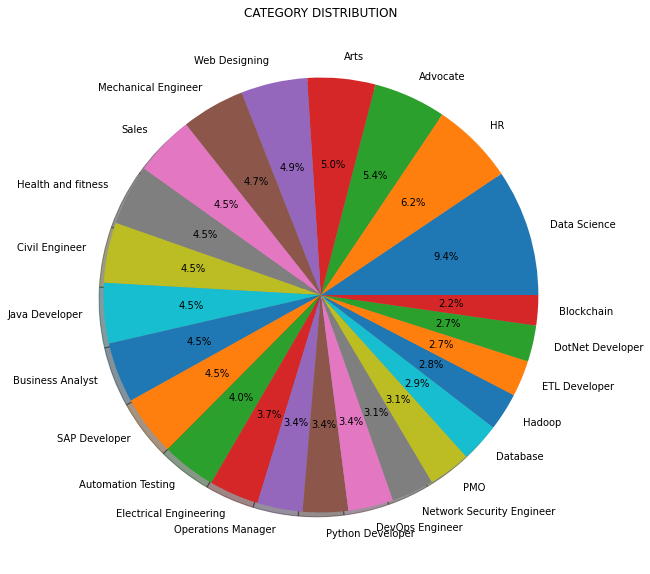

In [ ]:
# Pie graph visualization
from matplotlib.gridspec import GridSpec
targetCounts = data_set['Category'].value_counts()
targetLabels  = data_set['Category'].unique()
# Make square figures and axes
plt.figure(1, figsize=(22,22))
the_grid = GridSpec(2, 2)


cmap = plt.get_cmap('coolwarm')
plt.subplot(the_grid[0, 1], aspect=1, title='CATEGORY DISTRIBUTION')

source_pie = plt.pie(targetCounts, labels=targetLabels, autopct='%1.1f%%', shadow=True)
plt.show()

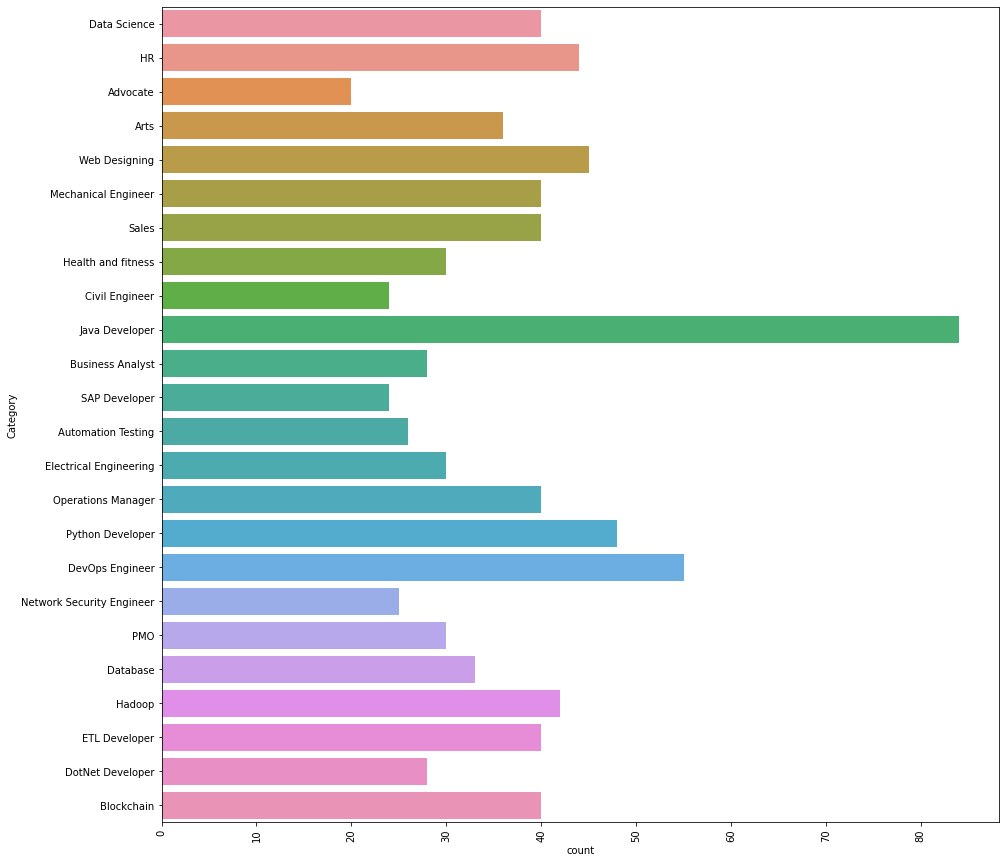

In [ ]:
# Bar graph visualization
plt.figure(figsize=(15,15))
plt.xticks(rotation=90)
sns.countplot(y="Category", data=data_set)

In [ ]:
# Get set of stopwords
stopwords_set = set(stopwords.words('english')+['``',"''"])
print(stopwords_set)

{"should've", 'then', 'off', 'it', 'those', 'above', "shan't", 'how', "hasn't", 'he', "weren't", "you'll", 'where', 'own', 'weren', 'theirs', 'for', 'again', 'very', 'these', 'down', 'through', 'nor', 'they', 'was', 'all', 'm', 'herself', 'wasn', 've', 'from', 'me', 'such', "wouldn't", 'out', 'whom', 'doing', 'why', 'not', 'shouldn', 'into', 'itself', 'themselves', "doesn't", 'just', 'i', "that'll", 'up', 'the', 'if', 'himself', 'and', 'should', 'them', 'of', 'same', 'at', 'now', 'couldn', 'when', 'an', "isn't", "''", 'there', 'her', 'll', 'wouldn', "you've", 'most', 'each', 'further', 'were', 'can', 'their', 'needn', 'aren', 'does', 'about', "aren't", 'by', "she's", 'am', 'ma', "needn't", 'that', 'than', 'has', 'are', 'before', 'on', 'o', 'because', 'too', 'him', "don't", 'yours', "you're", 'under', 'you', 'who', 'shan', 'which', 'once', 'being', 'mightn', 'ourselves', 'don', 'is', 'myself', 'doesn', 'having', 'other', 'both', 'she', 'no', "wasn't", 'a', 'during', 'few', "mightn't", '

In [ ]:
# Function to clean resume text
def clean_text(resume_text):
    resume_text = re.sub('http\S+\s*', ' ', resume_text)  # remove URLs
    resume_text = re.sub('RT|cc', ' ', resume_text)  # remove RT and cc
    resume_text = re.sub('#\S+', '', resume_text)  # remove hashtags
    resume_text = re.sub('@\S+', '  ', resume_text)  # remove mentions
    resume_text = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', resume_text)  # remove punctuations
    resume_text = re.sub(r'[^\x00-\x7f]',r' ', resume_text) 
    resume_text = re.sub('\s+', ' ', resume_text)  # remove extra whitespace
    resume_text = resume_text.lower()  # convert to lowercase
    resume_text_tokens = word_tokenize(resume_text)  # tokenize
    filtered_text = [w for w in resume_text_tokens if not w in stopwords_set]  # remove stopwords
    return ' '.join(filtered_text)

In [ ]:
# Print a sample original resume from dataset
print('--- Original resume ---')
print(data_set['Resume'][5])

--- Original resume ---
SKILLS C Basics, IOT, Python, MATLAB, Data Science, Machine Learning, HTML, Microsoft Word, Microsoft Excel, Microsoft Powerpoint. RECOGNITION Academic Secured First place in B.Tech.Education Details 
August 2014 to May 2018 B.Tech.  Ghatkesar, Andhra Pradesh Aurora's Scientific and Technological Institute
June 2012 to May 2014  Secondary Education Warangal, Telangana SR Junior College
Data Science 


Skill Details 
MS OFFICE- Exprience - Less than 1 year months
C- Exprience - Less than 1 year months
machine learning- Exprience - Less than 1 year months
data science- Exprience - Less than 1 year months
Matlab- Exprience - Less than 1 year monthsCompany Details 
company - 
description - 


In [ ]:
# Print the same resume after text cleaning
data_set['cleaned_resume'] = data_set.Resume.apply(lambda x: clean_text(x))

print('--- Cleaned resume ---')
print(data_set['cleaned_resume'][5])

--- Cleaned resume ---
skills c basics iot python matlab data science machine learning html microsoft word microsoft excel microsoft powerpoint recognition academic secured first place b tech education details august 2014 may 2018 b tech ghatkesar andhra pradesh aurora scientific technological institute june 2012 may 2014 secondary education warangal telangana sr junior college data science skill details ms office exprience less 1 year months c exprience less 1 year months machine learning exprience less 1 year months data science exprience less 1 year months matlab exprience less 1 year monthscompany details company description


In [ ]:
# Get features and labels from data and shuffle
features = data_set['cleaned_resume'].values
original_labels = data_set['Category'].values
labels = original_labels[:] #Slice Labels

for i in range(data_size):
  labels[i] = str(labels[i].lower())  # convert to lowercase
  labels[i] = labels[i].replace(" ", "")  # use hyphens to convert multi-token labels into single tokens

features, labels = shuffle(features, labels)

# Print example feature and label
print(features[0])
print(labels[0])

core competencies ant maven git bitbucket jenkins linux ansible shell scripting requirement gathering continuous integration continuous deployment software development life cycle software testing life cycle documentation reporting test reports skills primary skills dev ops methodologies programming languages c core java version controls git bitbucket build tools ant maven ci cd tools jenkins configuration management ansible scripting shell script application servers apache tomcat servereducation details june 2015 june 2017 masters science information technology hyderabad telangana jntu devops engineer devops engineer nendrasys technologies pvt ltd skill details deployment exprience 27 months git exprience 27 months documentation exprience 26 months change management exprience 10 months configuration management exprience 10 monthscompany details company nendrasys technologies pvt ltd description date project description scope project design develop e commerce product features sloan proj

In [ ]:
# Split for train and test
train_split = 0.8
train_size = int(train_split * data_size)

train_features = features[:train_size]
train_labels = labels[:train_size]

test_features = features[train_size:]
test_labels = labels[train_size:]

# Print size of each split
print(len(train_labels))
print(len(test_labels))

#print total Shapes
print('Shapes:' , train_labels.shape , test_labels.shape )

713
179
Shapes: (713,) (179,)


In [ ]:
# Tokenize feature data and print word dictionary
vocab_size = 6000
oov_tok = '<OOV>'

feature_tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
feature_tokenizer.fit_on_texts(features)

feature_index = feature_tokenizer.word_index
print(dict(list(feature_index.items())))

# Print example sequences from train and test datasets
train_feature_sequences = feature_tokenizer.texts_to_sequences(train_features)
print(train_feature_sequences[5])

test_feature_sequences = feature_tokenizer.texts_to_sequences(test_features)
print(test_feature_sequences[5])

{'<OOV>': 1, 'exprience': 2, 'company': 3, 'project': 4, 'months': 5, 'description': 6, 'details': 7, 'data': 8, '1': 9, 'management': 10, 'team': 11, 'year': 12, '6': 13, 'system': 14, 'maharashtra': 15, 'database': 16, 'development': 17, 'business': 18, 'less': 19, 'sql': 20, 'ltd': 21, 'using': 22, 'developer': 23, 'client': 24, 'java': 25, 'skill': 26, 'testing': 27, 'application': 28, 'pune': 29, 'engineering': 30, 'january': 31, 'services': 32, 'work': 33, 'skills': 34, 'c': 35, 'test': 36, 'software': 37, 'sales': 38, 'responsibilities': 39, 'pvt': 40, 'operations': 41, 'requirements': 42, 'reports': 43, 'education': 44, 'server': 45, 'technical': 46, 'process': 47, 'india': 48, 'customer': 49, 'various': 50, 'design': 51, 'technologies': 52, 'university': 53, 'working': 54, 'python': 55, 'monthscompany': 56, '2': 57, 'environment': 58, 'web': 59, 'like': 60, 'automation': 61, 'college': 62, 'support': 63, 'mysql': 64, 'worked': 65, 'role': 66, 'technology': 67, 'activities': 68

In [ ]:
# Tokenize label data and print label dictionary
label_tokenizer = Tokenizer(lower=True)
label_tokenizer.fit_on_texts(labels)

label_index = label_tokenizer.word_index
print(dict(list(label_index.items())))


# Print example label encodings from train and test datasets
train_label_sequences = label_tokenizer.texts_to_sequences(train_labels)
print(train_label_sequences[5])

test_label_sequences = label_tokenizer.texts_to_sequences(test_labels)
print(test_label_sequences[5])

{'javadeveloper': 1, 'devopsengineer': 2, 'pythondeveloper': 3, 'webdesigning': 4, 'hr': 5, 'hadoop': 6, 'datascience': 7, 'etldeveloper': 8, 'sales': 9, 'blockchain': 10, 'mechanicalengineer': 11, 'operationsmanager': 12, 'arts': 13, 'database': 14, 'healthandfitness': 15, 'pmo': 16, 'electricalengineering': 17, 'dotnetdeveloper': 18, 'businessanalyst': 19, 'automationtesting': 20, 'networksecurityengineer': 21, 'civilengineer': 22, 'sapdeveloper': 23, 'advocate': 24}
[24]
[5]


In [ ]:
# Pad sequences to ensure same length for feature data
max_length = 300
trunc_type = 'post'
pad_type = 'post'

train_feature_padded = pad_sequences(train_feature_sequences, maxlen=max_length, padding=pad_type, truncating=trunc_type)
test_feature_padded = pad_sequences(test_feature_sequences, maxlen=max_length, padding=pad_type, truncating=trunc_type)

# Print example padded sequences from train and test datasets
print(train_feature_padded[5])
print(test_feature_padded[5])

[1779 3490   86    1    7   31 1585   31 1207  517  985 1341 2138 2139
  382 5973  985   53   31 1901   31 1585  246  985 1341 2138 2139  382
 5973  985   53   31 2716   31 1901  246  488    1    1 2138 2139    1
    1   53 1538 1538   26    7    3    7    3    1    6  164 1810    1
    1   48 2717  329 1810 1341 5656 1076    1 1341 2420 4902 1341 3170
 2989 1586 1902 2989 4903  124 2989  891 3113    1  239   10 1341  137
  891 3113    1    1 1341    1  299  352  258    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0 

In [ ]:
#creating the neural network model with keras
embedding_dim = 64

model = tf.keras.Sequential([
  # Add an Embedding layer expecting input vocab of size 6000, and output embedding dimension of size 64 we set at the top
  tf.keras.layers.Embedding(vocab_size, embedding_dim, input_length=1),
  tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(embedding_dim)),

  # use ReLU in place of tanh function since they are very good alternatives of each other.
  tf.keras.layers.Dense(embedding_dim, activation='relu'),

  # Add a Dense layer with 25 units and softmax activation for probability distribution
  tf.keras.layers.Dense(25, activation='softmax')
])

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 1, 64)             384000    
                                                                 
 bidirectional_1 (Bidirectio  (None, 128)              66048     
 nal)                                                            
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 25)                1625      
                                                                 
Total params: 459,929
Trainable params: 459,929
Non-trainable params: 0
_________________________________________________________________


In [ ]:
# Alternative model
embedding_dim = 64

model = tf.keras.Sequential([
  # Add an Embedding layer expecting input vocab of size 6000, and output embedding dimension of size 64 we set at the top
  tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=1),
  #tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(embedding_dim)),
  #tf.keras.layers.Flatten(),
  #tf.keras.layers.GlobalAveragePooling1D(),
  tf.keras.layers.GlobalMaxPooling1D(),


  # use ReLU in place of tanh function since they are very good alternatives of each other.
  tf.keras.layers.Dense(128, activation='relu'),
  # Add a Dense layer with 25 units and softmax activation for probability distribution
  tf.keras.layers.Dense(25, activation='softmax'),
  #tf.keras.layers.Dense(1, activation='sigmoid'),
  #tf.keras.layers.Dense(1)

])

model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_4 (Embedding)     (None, 1, 64)             384000    
                                                                 
 global_max_pooling1d_1 (Glo  (None, 64)               0         
 balMaxPooling1D)                                                
                                                                 
 dense_8 (Dense)             (None, 128)               8320      
                                                                 
 dense_9 (Dense)             (None, 25)                3225      
                                                                 
Total params: 395,545
Trainable params: 395,545
Non-trainable params: 0
_________________________________________________________________


In [ ]:
# Compile the model and convert train/test data into NumPy arrays
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Features
train_feature_padded = np.array(train_feature_padded)
test_feature_padded = np.array(test_feature_padded)

# Labels
train_label_sequences = np.array(train_label_sequences)
test_label_sequences = np.array(test_label_sequences)

# Print example values
# print(train_feature_padded[0])
# print(train_label_sequences[0])
print(test_feature_padded[5])
print(test_label_sequences[5])

[ 44   7   1   1 491  53 358  26   7 171   2  13  56   7   3   6   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   

In [ ]:
# Train the neural network
num_epochs = 12  #Define Blocks for batch file

history = model.fit(train_feature_padded, train_label_sequences, epochs=num_epochs, validation_data=(test_feature_padded, test_label_sequences), verbose=2)

Epoch 1/12


23/23 - 12s - loss: 3.1910 - accuracy: 0.1501 - val_loss: 3.1133 - val_accuracy: 0.2346 - 12s/epoch - 524ms/step
Epoch 2/12
23/23 - 7s - loss: 2.9193 - accuracy: 0.1837 - val_loss: 2.6496 - val_accuracy: 0.1564 - 7s/epoch - 306ms/step
Epoch 3/12
23/23 - 7s - loss: 2.3576 - accuracy: 0.2623 - val_loss: 2.1157 - val_accuracy: 0.3464 - 7s/epoch - 297ms/step
Epoch 4/12
23/23 - 7s - loss: 1.8353 - accuracy: 0.4909 - val_loss: 1.6369 - val_accuracy: 0.5419 - 7s/epoch - 303ms/step
Epoch 5/12
23/23 - 7s - loss: 1.3907 - accuracy: 0.6045 - val_loss: 1.3121 - val_accuracy: 0.6536 - 7s/epoch - 291ms/step
Epoch 6/12
23/23 - 7s - loss: 1.0185 - accuracy: 0.7882 - val_loss: 1.0194 - val_accuracy: 0.7486 - 7s/epoch - 302ms/step
Epoch 7/12
23/23 - 8s - loss: 0.6857 - accuracy: 0.8527 - val_loss: 0.7743 - val_accuracy: 0.8603 - 8s/epoch - 365ms/step
Epoch 8/12
23/23 - 7s - loss: 0.5801 - accuracy: 0.8864 - val_loss: 0.4918 - val_accuracy: 0.9385 - 7s/epoch - 297ms/step
Epoch 9/12
23/23 - 7s - loss: 0.3

In [ ]:
# print example feature and its correct label
print(test_features[9])
print(test_labels[9])

education details bca vinayaka missions university operations manager operations manager skill details operations management exprience less 1 year monthscompany details company bny mellon international operations india pvt ltd description organization bny mellon international operations india pvt ltd sept 2009 till date bny mellon provides broad range products services areas investment management investment services treasury services customers institutions corporations high net worth individuals well consultants advisors work line business lob revenue billing services r bs revenue billing services global center excellence generates invoices collects fee revenue investment services clients 218 staff across five locations brooklyn pittsburgh syracuse pune uk various businesses supported asset servicing corporate trust treasury services broker dealer services global collateral management support u emea apac regions job profile operations manager bny mellon international operations india p

In [ ]:
# Create padded sequence for example
# resume_example = 'skills bitcoin ethereum solidity hyperledger beginner go beginner r3 corda beginner tendermint nodejs c programming java machine learning specilaized brain computer interface computer networking server admin computer vision data analytics cloud computing reactjs angulareducation details january 2014 january 2018 bachelor engineering computer science engineering thakur college engineering technology september 2016 march 2017 dynamic blood bank system mumbai maharashtra iit january 2014 cbse senior secondary january 2011 cbse banking vidyashram public school blockchain developer blockchain developer zhypility technologies skill details networking exprience 27 months data analytics exprience 11 months computer vision exprience 6 months java exprience 6 months machine learning exprience 6 monthscompany details company zhypility technologies description une 2018 company area business owner amway enterprise limited description business strategizing promotion analytics networking terms company virtual description developing prototype smart india hackthon deployment level 3 networking switch intern bharti airtel private limited mumbai company 1 international research scholar university rome tor vergata rome description nov 2017 nov 2017 done research reality based brain computer interface proposed paper international journal advanced research ijar 20656 epted paper reviewer smart kisan revolutionizing country ijsrd epted publication company description reliance jio mumbai dec 2017 jan 2017 company maharastra state government hackthon description company virtual description handling group interns marketing sales team nearby promote social media platform nearby products company promotion stock marketing drums foods international description company 8 data science web analytics positron internet virtual description company description making people aware women equality rights raise voice violence various modes events sources media help society company iit bombay iit kgp startup description company iit bombay iit kgp startup description'
resume_example = 'skills c basics iot python matlab data science machine learning html microsoft word microsoft excel microsoft powerpoint recognition academic secured first place b tech education details august 2014 may 2018 b tech ghatkesar andhra pradesh aurora scientific technological institute june 2012 may 2014 secondary education warangal telangana sr junior college data science skill details ms office exprience less 1 year months c exprience less 1 year months machine learning exprience less 1 year months data science exprience less 1 year months matlab exprience less 1 year monthscompany details company description'
example_sequence = feature_tokenizer.texts_to_sequences([resume_example])
example_padded = pad_sequences(example_sequence, maxlen=max_length, padding=pad_type, truncating=trunc_type)
example_padded = np.array(example_padded)
print(example_padded)

[[  34   35 1960 3006   55 1295    8  101  165  158  122  254  710  254
   317  254  924 1462 1176 1327  780 1170   92  301   44    7  630  219
   251  258   92  301    1 4576  649    1    1 2239  239  204  208  251
   219  459   44    1 1396  706 1320   62    8  101   26    7  111  140
     2   19    9   12    5   35    2   19    9   12    5  165  158    2
    19    9   12    5    8  101    2   19    9   12    5 1295    2   19
     9   12   56    7    3    6    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0   

In [ ]:
# Make a prediction
prediction = model.predict(example_padded)

In [ ]:
# Verify that prediction has correct format
print(prediction[0])
print(len(prediction[0]))  # should be 25
print(np.sum(prediction[0]))  # should be 1

[2.1024e-06 1.4394e-03 2.5718e-05 4.2426e-04 6.3788e-03 8.7949e-02
 8.3949e-05 8.7048e-01 2.5290e-04 1.9267e-04 2.6026e-05 1.2879e-03
 9.4553e-05 2.7517e-05 8.0281e-04 1.7460e-04 4.1575e-04 5.2680e-03
 2.4069e-04 2.3206e-04 2.5957e-03 4.4460e-03 1.6705e-02 2.1857e-05
 4.3340e-04]
25
0.9999999


In [ ]:
# Find maximum value in prediction and its index
print(max(prediction[0]))  # confidence in prediction (as a fraction of 1)
print(np.argmax(prediction[0])) # should be 11 which corresponds to blockchain

0.8704796
7


In [ ]:
# Indices of top 5 most probable solutions
indices = np.argpartition(prediction[0], -5)[-5:]
indices = indices[np.argsort(prediction[0][indices])]
indices = list(reversed(indices))
print(indices)

[7, 5, 22, 4, 17]


In [ ]:
# Save model
!mkdir -p saved_model
!ls
model.save('model/screen')

dictionary.pickle  feature_tokenizer.pickle  sample_data
drive		   model		     saved_model


In [ ]:
# Save feature tokenizer
with open('feature_tokenizer.pickle', 'wb') as handle:
    pickle.dump(feature_tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
# Save reverse dictionary of labels to encodings
label_to_encoding = dict(list(label_index.items()))
print('--------Label before encoding---------')
print(label_to_encoding)

encoding_to_label = {}
for k, v in label_to_encoding.items():
  encoding_to_label[v] = k

print('-----------------Label after encoding')
print(encoding_to_label)

with open('dictionary.pickle', 'wb') as handle:
    pickle.dump(encoding_to_label, handle, protocol=pickle.HIGHEST_PROTOCOL)

--------Label before encoding---------
{'javadeveloper': 1, 'devopsengineer': 2, 'pythondeveloper': 3, 'webdesigning': 4, 'hr': 5, 'hadoop': 6, 'datascience': 7, 'etldeveloper': 8, 'sales': 9, 'blockchain': 10, 'mechanicalengineer': 11, 'operationsmanager': 12, 'arts': 13, 'database': 14, 'healthandfitness': 15, 'pmo': 16, 'electricalengineering': 17, 'dotnetdeveloper': 18, 'businessanalyst': 19, 'automationtesting': 20, 'networksecurityengineer': 21, 'civilengineer': 22, 'sapdeveloper': 23, 'advocate': 24}
-----------------Label after encoding
{1: 'javadeveloper', 2: 'devopsengineer', 3: 'pythondeveloper', 4: 'webdesigning', 5: 'hr', 6: 'hadoop', 7: 'datascience', 8: 'etldeveloper', 9: 'sales', 10: 'blockchain', 11: 'mechanicalengineer', 12: 'operationsmanager', 13: 'arts', 14: 'database', 15: 'healthandfitness', 16: 'pmo', 17: 'electricalengineering', 18: 'dotnetdeveloper', 19: 'businessanalyst', 20: 'automationtesting', 21: 'networksecurityengineer', 22: 'civilengineer', 23: 'sapdev

In [ ]:
#Should return corresponding title ex: BlockChain

# print(encoding_to_label[np.argmax(prediction[0])]) 

# print(f'{encoding_to_label[np.argmax(prediction[0])]}')
# #prediction confidence
print(max(prediction[0]))

# #Top 5 Titles 
for i in indices:
  print(i, encoding_to_label[i])



0.8704796
7 datascience
5 hr
22 civilengineer
4 webdesigning
17 electricalengineering
